<a href="https://colab.research.google.com/github/DrTkachuk/RobustnessOfTensegrityFormFindingViaRankMinimization/blob/main/TensegrityExample2_6node_plane_with_constraints.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook implements an example 2
Tkachuk, A. (2022). Robustness of rank minimization heuristics for form-finding of tensegrity structures. Computers & Structures, 266, 106786.

In [32]:
import numpy as np
from numpy.linalg import matrix_rank
import cvxpy as cp

In [33]:
# Input
nele = 9
nnode = 6
# connectivity matrix
ID = np.array([[1, 5], [2, 6], [3, 5], [4, 6], [1, 2], [3, 4], [1, 3], [2, 4], [5, 6]])
print(ID)
# dummy flag for vizualization - 1 means green dashed line or dummy truss
dummyflag = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1])
# sign of force densities: +1 - cabel/tension; -1 - compression
SigM = np.diag([1,1,1,1,1,1,-1,-1,-1])
print(dummyflag)
#prescribed nodal location, always last 3 nodes
xbar=np.array([5.25,0,7])
ybar=np.array([-2.0,0,0])
#constraint constant between force densities q1 and q2, works between
eta = 0.04
#sign offset for the force densities
epsilon=0.01
#parameter of log-det heuristics
delta=0.0001
num_iter=5
#tolerance for rank definition
rank_tol = 1e-7

[[1 5]
 [2 6]
 [3 5]
 [4 6]
 [1 2]
 [3 4]
 [1 3]
 [2 4]
 [5 6]]
[0 0 0 0 0 0 0 0 1]


In [34]:
#node-edge incidence matrix
C = np.zeros((nnode,nele))
for i in range(nele):
    C[ID[i,0]-1,i] = -1
    C[ID[i,1]-1,i] = 1
print(C)

[[-1.  0.  0.  0. -1.  0. -1.  0.  0.]
 [ 0. -1.  0.  0.  1.  0.  0. -1.  0.]
 [ 0.  0. -1.  0.  0. -1.  1.  0.  0.]
 [ 0.  0.  0. -1.  0.  1.  0.  1.  0.]
 [ 1.  0.  1.  0.  0.  0.  0.  0. -1.]
 [ 0.  1.  0.  1.  0.  0.  0.  0.  1.]]


In [35]:
# definition of cvxpy problem
# force densities are the only variables
Q = cp.Variable(nele)

# initialization of weighting matrix
W = np.eye(nnode,nnode)
#rank history
rank_hist=[]

for i in range(num_iter):
    # definition of cost and constraints
    cost=cp.trace(W @ C @ cp.diag(Q) @ C.T)
    constraints = [epsilon <= SigM @ Q, cp.PSD(C @ cp.diag(Q) @ C.T), Q[1] == eta*Q[2]]
    # creating problem object
    prob = cp.Problem(cp.Minimize(cost), constraints=constraints)
    prob.solve()
    #history of rank change
    rank_hist.append(int(matrix_rank (C @ np.diag(Q.value) @ C.T, tol=rank_tol, hermitian=True)))
    #updating the weight
    W =np.linalg.inv( C @ np.diag(Q.value) @ C.T + delta * np.eye(nnode,nnode))

print(Q.value/epsilon)
print(rank_hist)




[ 2.06071691  1.00000288 25.0000721   2.02217364  1.00000027  1.09199448
 -0.99999998 -0.99999854 -1.04262211]
[5, 3, 4, 4, 3]


In [36]:
rank_achieved= matrix_rank (C @ np.diag(Q.value) @ C.T, tol=rank_tol, hermitian=True)

In [37]:
# recovery of the geometry from the nullspace of the force density matrix
# first, full SVD decompostion
U, S, Vh = np.linalg.svd(C @ np.diag(Q.value) @ C.T, full_matrices=True,hermitian=True)

In [38]:
#slicing the vectors and finding equations
phi = U[:,(nnode-3):nnode]
Kgeom=phi[(nnode-3):nnode,:]
# finding the nodal position as linear combination of the nulspace vectors
alpha = np.linalg.solve(Kgeom,xbar)
beta = np.linalg.solve(Kgeom,ybar)
# final vector of nodal positions
xstar= phi @ alpha
ystar= phi @ beta
print(xstar)
print(ystar)

[1.49044421e+00 3.24046039e+00 1.69078385e-01 5.25000000e+00
 6.06436630e-16 7.00000000e+00]
[ 2.04435903e+00  4.04433363e+00 -1.68513326e-01 -2.00000000e+00
 -8.07366352e-17  4.17864618e-18]


In [39]:
#check recovering geometry to fullfil the homogeneous equilibrium conditions
print(np.linalg.norm(C @ np.diag(Q.value) @ C.T @ xstar))
print(np.linalg.norm(C @ np.diag(Q.value) @ C.T @ ystar))

3.9378093873710717e-08
6.758138746721001e-08


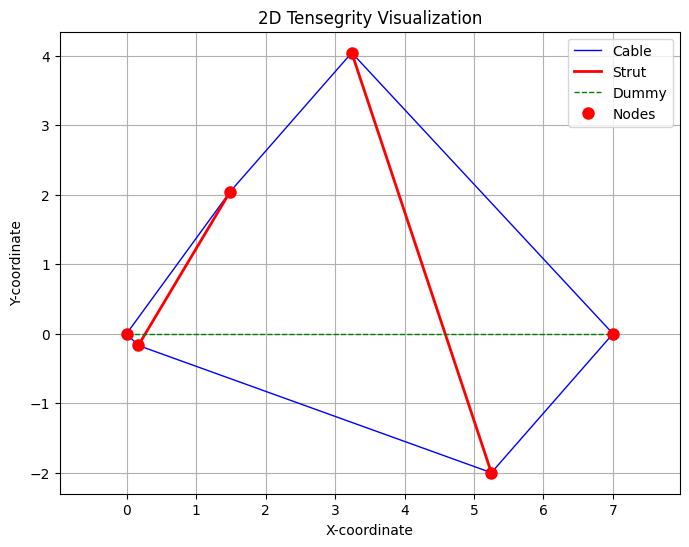

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

cable_label_added = False
strut_label_added = False
dummy_label_added = False

for i in range(nele):
    node1 = ID[i, 0] - 1  # Adjust for 0-based indexing
    node2 = ID[i, 1] - 1  # Adjust for 0-based indexing

    x_coords = [xstar[node1], xstar[node2]]
    y_coords = [ystar[node1], ystar[node2]]

    if SigM[i,i] == 1:
        label = 'Cable' if not cable_label_added else ''
        plt.plot(x_coords, y_coords, 'b-', linewidth=1, label=label)
        cable_label_added = True
    elif dummyflag[i] == 0:
        label = 'Strut' if not strut_label_added else ''
        plt.plot(x_coords, y_coords, 'r-', linewidth=2, label=label )
        strut_label_added = True
    else:
        label = 'Dummy' if not dummy_label_added else ''
        plt.plot(x_coords, y_coords, 'g--', linewidth=1, label=label)
        dummy_label_added = True

# Plot nodes
plt.plot(xstar, ystar, 'ro', markersize=8, label='Nodes')

plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.title('2D Tensegrity Visualization')
plt.grid(True)
plt.axis('equal') # Ensure proper aspect ratio for 2D structure
plt.legend()
plt.show()